# Visualización

Los árboles de decisión son muy fáciles de visualizar e interpretar:

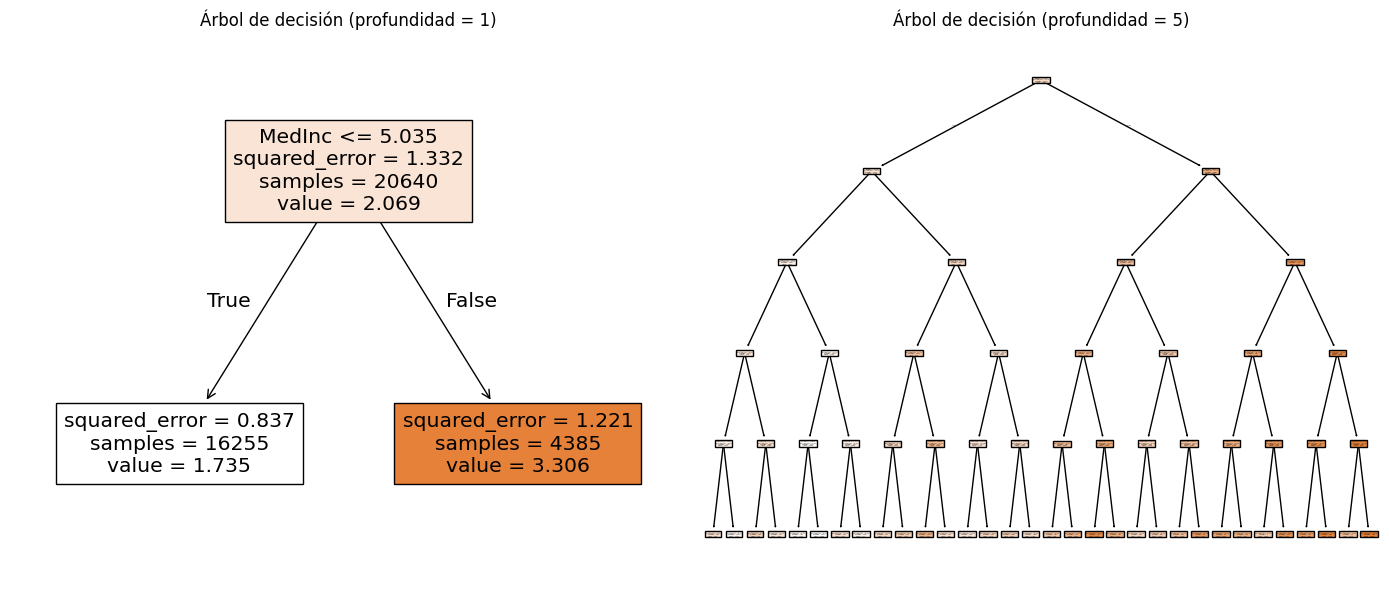

In [1]:
from sklearn.datasets import fetch_california_housing
from sklearn.tree import DecisionTreeRegressor, plot_tree
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

# Cargar California Housing Dataset
california = fetch_california_housing()

X = california.data
y = california.target

# Ajustar árbol con profundidad máxima de 1
dt1 = DecisionTreeRegressor(max_depth=1)
dt1.fit(X, y)

# Ajustar árbol con profundidad máxima de 5
dt5 = DecisionTreeRegressor(max_depth=5)
dt5.fit(X, y)

# Visualizar los árboles
fig, ax = plt.subplots(1, 2, figsize=(14, 6))
plot_tree(dt1, ax=ax[0], filled=True, feature_names=california.feature_names)
ax[0].set_title("Árbol de decisión (profundidad = 1)")
plot_tree(dt5, ax=ax[1], filled=True, feature_names=california.feature_names)
ax[1].set_title("Árbol de decisión (profundidad = 5)")
plt.tight_layout()
plt.show()

# Explicabilidad

Igualmente, es fácil explicar por qué una observación es clasificada de cierta manera por un árbol de decisión:

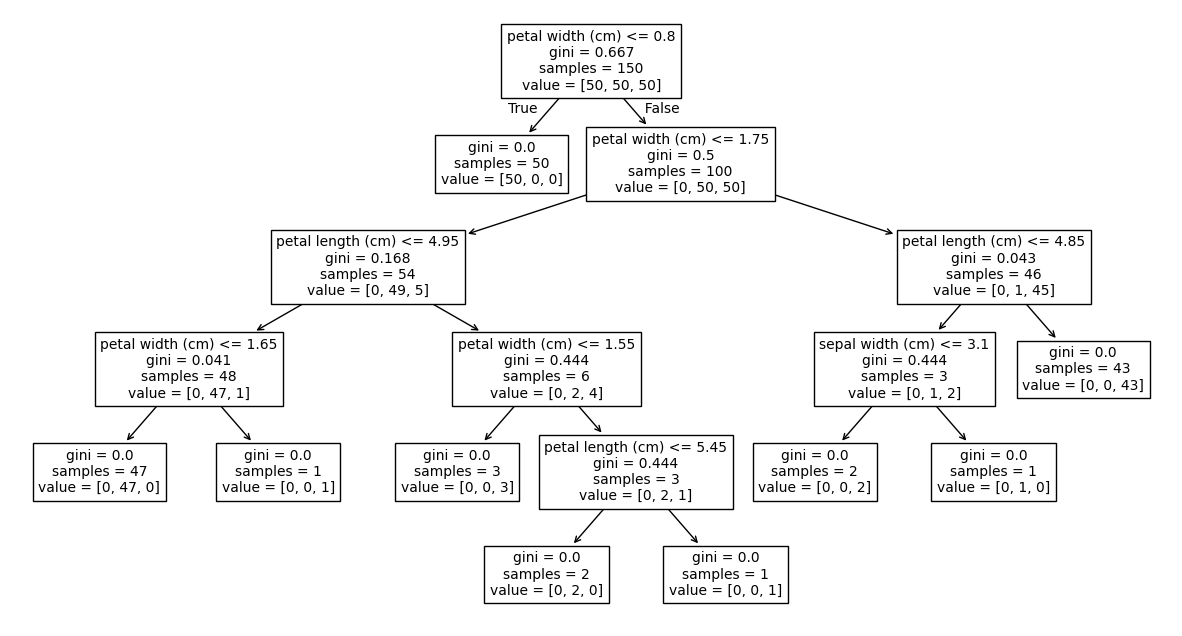

In [2]:
from sklearn.datasets import load_iris
from sklearn.tree import DecisionTreeClassifier, plot_tree
   
# Cargar dataset Iris
iris = load_iris()

# Crear clasificador de árbol de decisión
clf = DecisionTreeClassifier(random_state=0, max_depth=5)
clf.fit(iris.data, iris.target)

# Visualizar el árbol
plt.figure(figsize=(15,8))
plot_tree(clf, fontsize=10, feature_names=iris.feature_names)
plt.show()

In [3]:
# Función para explicar por qué una observación es clasificada de cierta manera
def explanation_prediction(clf, observation):
    # Recorrer el árbol de decisión para explicar la predicción
    node_index = 0
    while clf.tree_.children_left[node_index] != -1:
        feature_index = clf.tree_.feature[node_index]
        threshold = clf.tree_.threshold[node_index]
        if observation[0][feature_index] <= threshold:
            node_index = clf.tree_.children_left[node_index]
            print(f"Ir al nodo {node_index}: {iris.feature_names[feature_index]} <= {threshold}")
        else:
            node_index = clf.tree_.children_right[node_index]
            print(f"Ir al nodo {node_index}: {iris.feature_names[feature_index]} > {threshold}")

    # Imprimir la clase predicha
    prediction = clf.predict(observation)[0]
    print(f"La observación {observation[0]} se predice como clase {iris.target_names[prediction]}")


# Definir una observación para explicar su predicción
observation = [[0.1, 3.6, 1.4, 4.5]]  # nueva observación
explanation_prediction(clf, observation)

Ir al nodo 2: petal width (cm) > 0.800000011920929
Ir al nodo 12: petal width (cm) > 1.75
Ir al nodo 13: petal length (cm) <= 4.8500001430511475
Ir al nodo 15: sepal width (cm) > 3.100000023841858
La observación [0.1, 3.6, 1.4, 4.5] se predice como clase versicolor


# Overfitting

Modelos de árboles pueden hacer overfitting de los datos muy fácilmente. Son propensos a hacer overfitting en particular con hiperparámetros como la profundidad del árbol o el mínimo de observaciones en cada nodo terminal.

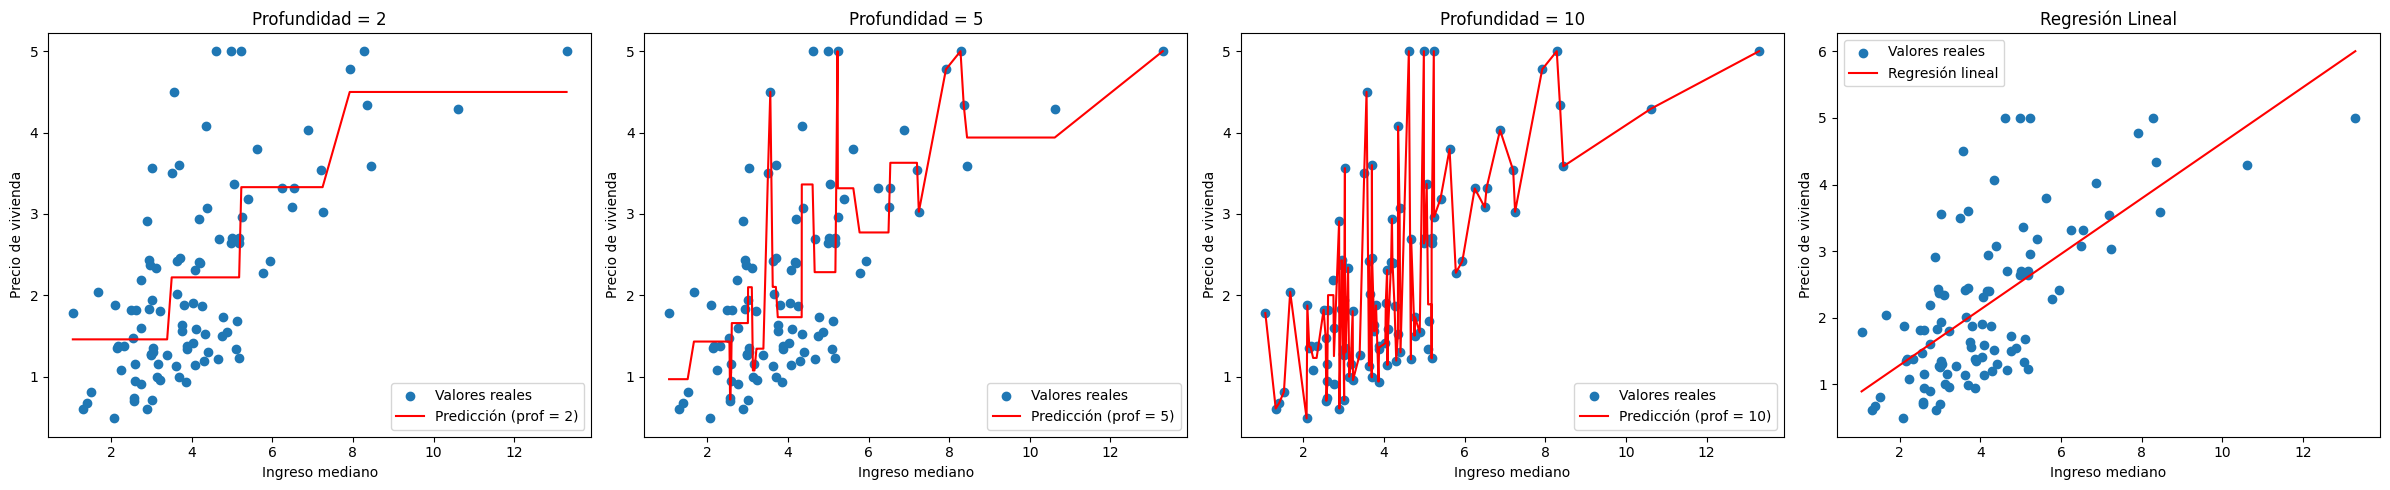

In [4]:
from sklearn.datasets import fetch_california_housing
from sklearn.tree import DecisionTreeRegressor
from sklearn.linear_model import LinearRegression
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

# Cargar California Housing Dataset
california = fetch_california_housing()

# Seleccionar una sola variable predictora (MedInc = ingreso mediano)
idx = np.random.choice(len(california.target), size=100, replace=False)
X = california.data[idx, 0]  # MedInc
y = california.target[idx]

# Ordenar por X
idx = X.argsort()
X = X[idx]
y = y[idx]

# Distintas profundidades
max_depths = [2, 5, 10]

fig, axs = plt.subplots(1, 4, figsize=(24, 5))

for i, depth in enumerate(max_depths):
    dt = DecisionTreeRegressor(max_depth=depth)
    dt.fit(X.reshape(-1, 1), y)
    y_pred = dt.predict(X.reshape(-1, 1))
    axs[i].scatter(X, y, label='Valores reales')
    axs[i].plot(X, y_pred, color='red', label=f'Predicción (prof = {depth})')
    axs[i].set_xlabel('Ingreso mediano')
    axs[i].set_ylabel('Precio de vivienda')
    axs[i].set_title(f'Profundidad = {depth}')
    axs[i].legend()

# Regresión lineal para comparar
reg = LinearRegression()
reg.fit(X.reshape(-1, 1), y)
y_pred_reg = reg.predict(X.reshape(-1, 1))

axs[-1].scatter(X, y, label='Valores reales')
axs[-1].plot(X, y_pred_reg, color='red', label='Regresión lineal')
axs[-1].set_xlabel('Ingreso mediano')
axs[-1].set_ylabel('Precio de vivienda')
axs[-1].set_title('Regresión Lineal')
axs[-1].legend()

plt.tight_layout()
plt.show()

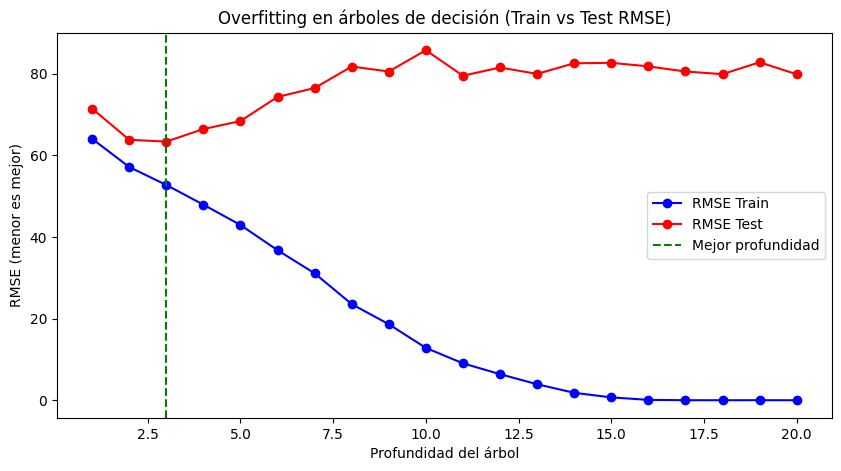

In [5]:
from sklearn.datasets import load_diabetes
from sklearn.tree import DecisionTreeRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error
import numpy as np
import matplotlib.pyplot as plt
import warnings

warnings.filterwarnings('ignore')

# Cargar dataset
data = load_diabetes()
X = data.data  # Usar todas las variables
y = data.target

# Dividir en train y test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

# Rango de profundidades a probar
depths = range(1, 21)

# Almacenar RMSE
train_rmse = []
test_rmse = []

for depth in depths:
    dt = DecisionTreeRegressor(max_depth=depth)
    dt.fit(X_train, y_train)
    
    # Calcular RMSE
    train_rmse.append(np.sqrt(mean_squared_error(y_train, dt.predict(X_train))))
    test_rmse.append(np.sqrt(mean_squared_error(y_test, dt.predict(X_test))))

# Graficar RMSE de entrenamiento vs test
plt.figure(figsize=(10, 5))
plt.plot(depths, train_rmse, marker='o', label="RMSE Train", color='blue')
plt.plot(depths, test_rmse, marker='o', label="RMSE Test", color='red')

plt.xlabel("Profundidad del árbol")
plt.ylabel("RMSE (menor es mejor)")
plt.title("Overfitting en árboles de decisión (Train vs Test RMSE)")
plt.axvline(x=np.argmin(test_rmse) + 1, color="green", linestyle="--", label="Mejor profundidad")
plt.legend()
plt.show()

# Cambios en árbol con distintos datos

Los árboles de decisión pueden cambiar bastante si se cambia el conjunto de entrenamiento de los datos:

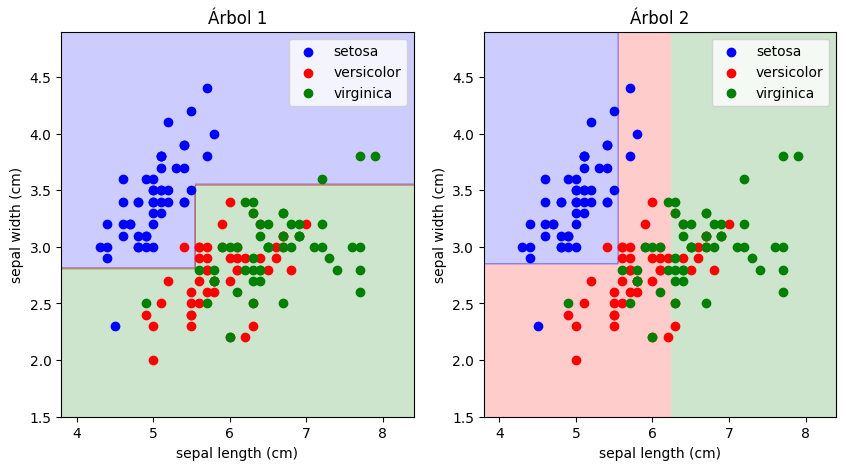

In [6]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
from sklearn.datasets import load_iris
from sklearn.tree import DecisionTreeClassifier

# Cargar dataset Iris
iris = load_iris()
X = iris.data[:, :2]  # Seleccionar solo las primeras dos variables para visualizar
y = iris.target

# Definir colores para cada clase
colors = ['blue', 'red', 'green']
cmap = ListedColormap(colors)

# Entrenar dos árboles con conjuntos de entrenamiento ligeramente distintos
tree1 = DecisionTreeClassifier(max_depth=2, random_state=0)
tree1.fit(X[:75], y[:75])

tree2 = DecisionTreeClassifier(max_depth=2, random_state=1)
tree2.fit(X[25:], y[25:])

# Graficar las fronteras de decisión
x_min, x_max = X[:, 0].min() - 0.5, X[:, 0].max() + 0.5
y_min, y_max = X[:, 1].min() - 0.5, X[:, 1].max() + 0.5
xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.02),
                     np.arange(y_min, y_max, 0.02))

fig, ax = plt.subplots(nrows=1, ncols=2, figsize=(10, 5))

for i, tree in enumerate([tree1, tree2]):
    Z = tree.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)
    ax[i].contourf(xx, yy, Z, alpha=0.2, cmap=cmap)
    ax[i].scatter(X[y == 0, 0], X[y == 0, 1], c='blue', label=iris.target_names[0])
    ax[i].scatter(X[y == 1, 0], X[y == 1, 1], c='red', label=iris.target_names[1])
    ax[i].scatter(X[y == 2, 0], X[y == 2, 1], c='green', label=iris.target_names[2])
    ax[i].set_xlabel(iris.feature_names[0])
    ax[i].set_ylabel(iris.feature_names[1])
    ax[i].set_title(f"Árbol {i+1}")
    ax[i].legend()

plt.show()

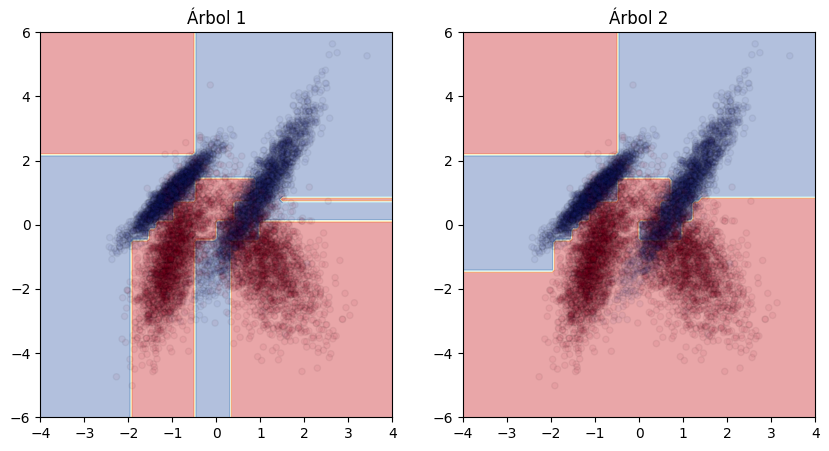

In [7]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_classification
from sklearn.tree import DecisionTreeClassifier

n_samples = 10000

# Generar dataset de clasificación con 2 variables
X, y = make_classification(n_samples=n_samples, n_features=2, n_informative=2,
                            n_redundant=0, n_classes=2, random_state=0)

# Entrenar dos árboles con conjuntos ligeramente distintos
tree1 = DecisionTreeClassifier(max_depth=5, random_state=0)
tree1.fit(X[:int(0.75*n_samples)], y[:int(0.75*n_samples)])

tree2 = DecisionTreeClassifier(max_depth=5, random_state=1)
tree2.fit(X[int(0.25*n_samples):], y[int(0.25*n_samples):])

# Graficar datos y fronteras de decisión
fig, ax = plt.subplots(nrows=1, ncols=2, figsize=(10, 5))

for i, tree in enumerate([tree1, tree2]):
    xx, yy = np.meshgrid(np.linspace(-4, 4, 100), np.linspace(-6, 6, 100))
    Z = tree.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)
    ax[i].contourf(xx, yy, Z, alpha=0.4, cmap=plt.cm.RdYlBu)
    ax[i].scatter(X[:, 0], X[:, 1], c=y, cmap=plt.cm.RdYlBu, s=20, edgecolors='k', alpha=0.05)
    ax[i].set_title(f"Árbol {i+1}")

plt.show()

# Outliers

Los árboles de decisión no cambian mucho si las variables predictivas son más o menos extremas. Es decir, si a un punto que está siendo enviado a la rama derecha de un árbol de acuerdo a la variable X se le aumenta el valor a X, el árbol no cambia en absolutamente nada:

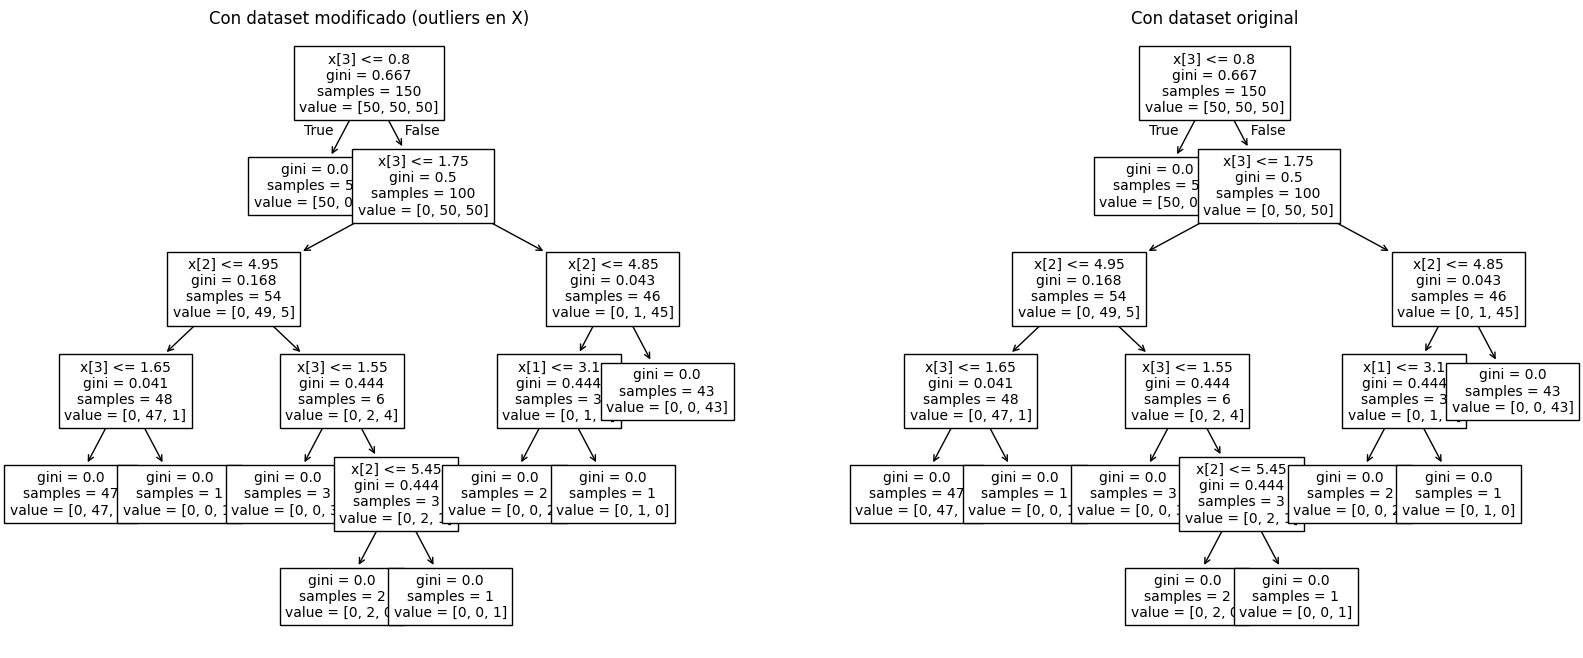

In [8]:
from sklearn.datasets import load_iris
from sklearn.tree import DecisionTreeClassifier, plot_tree
import numpy as np
import matplotlib.pyplot as plt

# Cargar dataset Iris
iris = load_iris()

# Modificar el dataset multiplicando las observaciones más extremas por un número grande
multiplier = 1000
X_modified = iris.data.copy()
X_modified[np.argmax(X_modified[:, 0]), 0] *= multiplier
X_modified[np.argmin(X_modified[:, 0]), 0] *= multiplier

# Crear árbol con el dataset modificado
clf_modified = DecisionTreeClassifier(random_state=0)
clf_modified.fit(X_modified, iris.target)

# Crear árbol con el dataset original
clf = DecisionTreeClassifier(random_state=0)
clf.fit(iris.data, iris.target)

# Visualizar ambos árboles lado a lado
fig, axs = plt.subplots(nrows=1, ncols=2, figsize=(20, 8))
plot_tree(clf_modified, fontsize=10, ax=axs[0])
axs[0].set_title("Con dataset modificado (outliers en X)")
plot_tree(clf, fontsize=10, ax=axs[1])
axs[1].set_title("Con dataset original")

plt.show()

Las predicciones tampoco cambian mucho si hay outliers en la variable de resultado. La razón es que cambios en la variable de resultado probablemente cambiarán un poco la predicción en la hoja donde cae esa observación (y pueden cambiar también el árbol entero), pero los cambios suelen ser moderados comparados con modelos paramétricos, como una regresión lineal:

In [9]:
from sklearn.datasets import fetch_california_housing
from sklearn.tree import DecisionTreeRegressor
from sklearn.linear_model import LinearRegression
import numpy as np

# Cargar California Housing
data = fetch_california_housing()
X = data.data
y = data.target

# Introducir outliers en la variable objetivo
y_modified = y.copy()
y_modified[np.argmax(X[:, 0])] = 10000   # Valor extremadamente alto
y_modified[np.argmin(X[:, 0])] = -10000   # Valor extremadamente bajo

# Entrenar modelos con la variable objetivo original
dt_reg = DecisionTreeRegressor(max_depth=5)
dt_reg.fit(X, y)

lr = LinearRegression()
lr.fit(X, y)

# Entrenar modelos con la variable objetivo modificada (con outliers)
dt_reg_modified = DecisionTreeRegressor(max_depth=5)
dt_reg_modified.fit(X, y_modified)

lr_modified = LinearRegression()
lr_modified.fit(X, y_modified)

# Generar dataset de prueba grande (5000 muestras)
np.random.seed(42)
X_test = X[np.random.choice(X.shape[0], 5000, replace=True)]

# Predecir con ambos modelos
y_pred_dt_original = dt_reg.predict(X_test)
y_pred_dt_modified = dt_reg_modified.predict(X_test)

y_pred_lr_original = lr.predict(X_test)
y_pred_lr_modified = lr_modified.predict(X_test)

# Calcular porcentaje de predicciones similares (tolerancia < 1)
match_percentage_dt = np.mean(np.abs(y_pred_dt_original - y_pred_dt_modified) < 1) * 100
match_percentage_lr = np.mean(np.abs(y_pred_lr_original - y_pred_lr_modified) < 1) * 100

# Imprimir resultados
print("\nRobustez a outliers:")
print(f"Árbol de decisión (max_depth=5) - Predicciones similares: {match_percentage_dt:.2f}%")
print(f"Regresión lineal - Predicciones similares: {match_percentage_lr:.2f}%")


Robustez a outliers:
Árbol de decisión (max_depth=5) - Predicciones similares: 99.06%
Regresión lineal - Predicciones similares: 17.60%


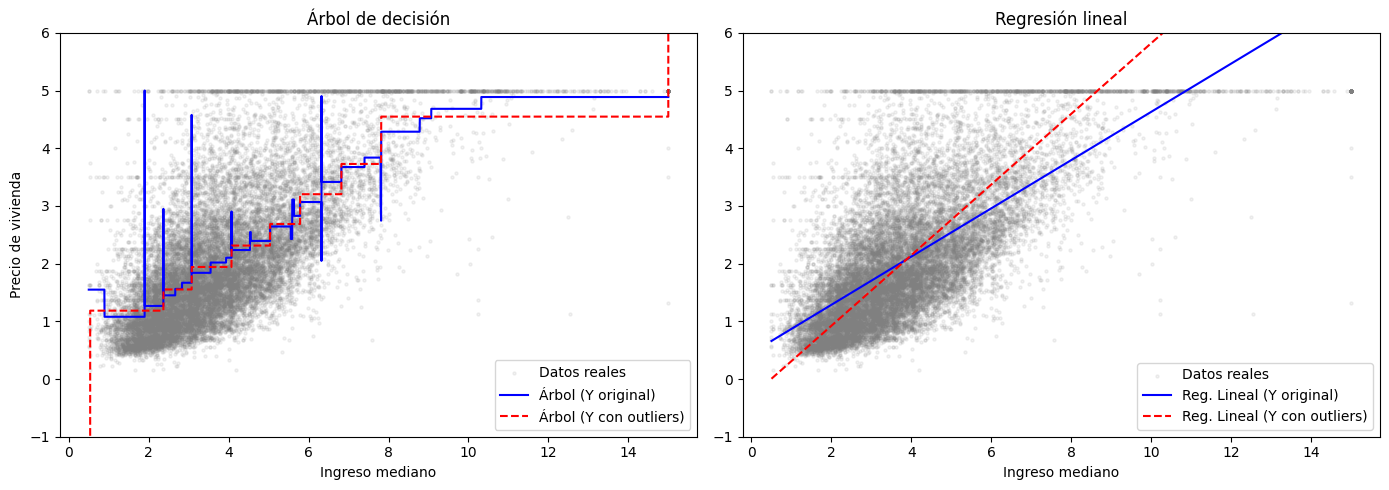

In [20]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import fetch_california_housing
from sklearn.tree import DecisionTreeRegressor
from sklearn.linear_model import LinearRegression

# Cargar California Housing
data = fetch_california_housing()
X = data.data
y = data.target

# Usar ingreso mediano (variable 0)
X_feature = X[:, 0].reshape(-1, 1)

# Introducir outliers extremos en Y
y_modified = y.copy()
y_modified[np.argmax(X_feature)] = 1000
y_modified[np.argmin(X_feature)] = -1000

# Entrenar modelos
dt_original = DecisionTreeRegressor(max_depth=5, random_state=0)
dt_original.fit(X_feature, y)

dt_modified = DecisionTreeRegressor(max_depth=5, random_state=0)
dt_modified.fit(X_feature, y_modified)

lr_original = LinearRegression()
lr_original.fit(X_feature, y)

lr_modified = LinearRegression()
lr_modified.fit(X_feature, y_modified)

# Generar predicciones
X_sorted = np.sort(X_feature.flatten()).reshape(-1, 1)

# Graficar datos y predicciones
fig, axs = plt.subplots(1, 2, figsize=(14, 5))

axs[0].scatter(X_feature, y, alpha=0.1, s=5, color='gray', label='Datos reales')
axs[0].plot(X_sorted, dt_original.predict(X_sorted), color='blue', label='Árbol (Y original)')
axs[0].plot(X_sorted, dt_modified.predict(X_sorted), color='red', linestyle='--', label='Árbol (Y con outliers)')
axs[0].set_title('Árbol de decisión')
axs[0].set_xlabel('Ingreso mediano')
axs[0].set_ylabel('Precio de vivienda')
axs[0].set_ylim(-1, 6)
axs[0].legend()

axs[1].scatter(X_feature, y, alpha=0.1, s=5, color='gray', label='Datos reales')
axs[1].plot(X_sorted, lr_original.predict(X_sorted), color='blue', label='Reg. Lineal (Y original)')
axs[1].plot(X_sorted, lr_modified.predict(X_sorted), color='red', linestyle='--', label='Reg. Lineal (Y con outliers)')
axs[1].set_title('Regresión lineal')
axs[1].set_xlabel('Ingreso mediano')
axs[1].set_ylim(-1, 6)
axs[1].legend()

plt.tight_layout()
plt.show()

# Extrapolación

Los árboles de decisión son malos para extrapolar:

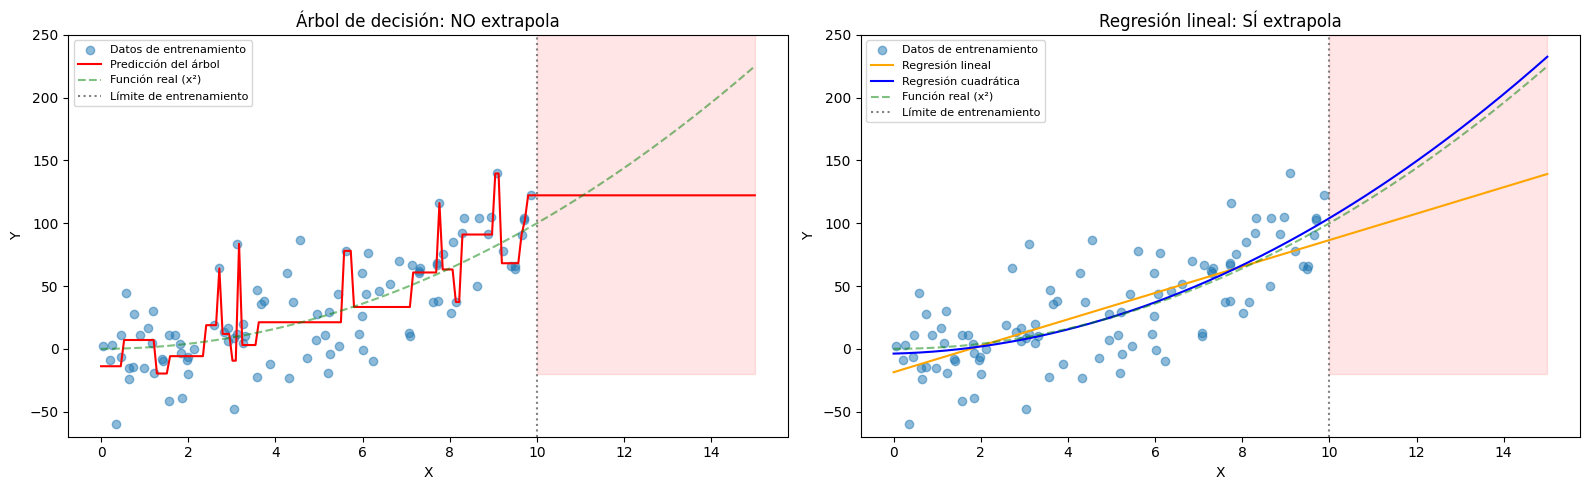

Izquierda: el árbol repite la predicción del último nodo fuera del rango de entrenamiento.
Derecha: la regresión lineal y cuadrática sí capturan la tendencia en la zona de extrapolación.
La regresión cuadrática casi coincide con la función real (x²).


In [11]:
from sklearn.tree import DecisionTreeRegressor
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures
import numpy as np
import matplotlib.pyplot as plt

# Generar datos con relación cuadrática
np.random.seed(42)
X_train = np.sort(np.random.uniform(0, 10, 100)).reshape(-1, 1)
y_train = X_train.ravel() ** 2 + np.random.normal(0, 30, 100)

# Datos de extrapolación (fuera del rango de entrenamiento)
X_extrap = np.linspace(0, 15, 200).reshape(-1, 1)

# Ajustar modelos
dt = DecisionTreeRegressor(max_depth=5)
dt.fit(X_train, y_train)

lr = LinearRegression()
lr.fit(X_train, y_train)

poly = PolynomialFeatures(degree=2)
X_train_poly = poly.fit_transform(X_train)
lr_quad = LinearRegression()
lr_quad.fit(X_train_poly, y_train)

# Predecir
y_pred_dt = dt.predict(X_extrap)
y_pred_lr = lr.predict(X_extrap)
y_pred_quad = lr_quad.predict(poly.transform(X_extrap))

# Graficar
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Panel izquierdo: Árbol de decisión
ax = axes[0]
ax.scatter(X_train, y_train, alpha=0.5, label='Datos de entrenamiento')
ax.plot(X_extrap, y_pred_dt, color='red', label='Predicción del árbol')
ax.plot(X_extrap, X_extrap.ravel()**2, color='green', linestyle='--', alpha=0.5, label='Función real (x²)')
ax.axvline(x=10, color='gray', linestyle=':', label='Límite de entrenamiento')
ax.fill_between([10, 15], -20, 250, alpha=0.1, color='red')
ax.set_xlabel('X')
ax.set_ylabel('Y')
ax.set_title('Árbol de decisión: NO extrapola')
ax.legend(fontsize=8)
ax.set_ylim(-70, 250)

# Panel derecho: Regresiones lineales
ax = axes[1]
ax.scatter(X_train, y_train, alpha=0.5, label='Datos de entrenamiento')
ax.plot(X_extrap, y_pred_lr, color='orange', label='Regresión lineal')
ax.plot(X_extrap, y_pred_quad, color='blue', label='Regresión cuadrática')
ax.plot(X_extrap, X_extrap.ravel()**2, color='green', linestyle='--', alpha=0.5, label='Función real (x²)')
ax.axvline(x=10, color='gray', linestyle=':', label='Límite de entrenamiento')
ax.fill_between([10, 15], -20, 250, alpha=0.1, color='red')
ax.set_xlabel('X')
ax.set_ylabel('Y')
ax.set_title('Regresión lineal: SÍ extrapola')
ax.legend(fontsize=8)
ax.set_ylim(-70, 250)

plt.tight_layout()
plt.show()

print("Izquierda: el árbol repite la predicción del último nodo fuera del rango de entrenamiento.")
print("Derecha: la regresión lineal y cuadrática sí capturan la tendencia en la zona de extrapolación.")
print("La regresión cuadrática casi coincide con la función real (x²).")


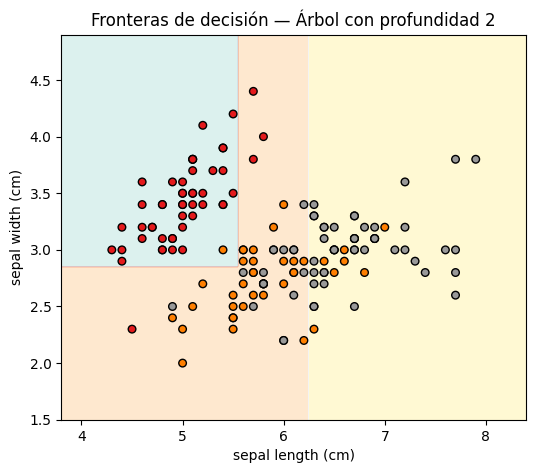

In [12]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_iris
from sklearn.tree import DecisionTreeClassifier

# Cargar dataset Iris
iris = load_iris()
X = iris.data[:, :2]  # Solo las primeras dos variables para visualizar
y = iris.target

# Entrenar árbol con un subconjunto diferente
tree1 = DecisionTreeClassifier(max_depth=2, random_state=0)
tree1.fit(X[25:], y[25:])

# Graficar fronteras de decisión
x_min, x_max = X[:, 0].min() - 0.5, X[:, 0].max() + 0.5
y_min, y_max = X[:, 1].min() - 0.5, X[:, 1].max() + 0.5
xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.02),
                     np.arange(y_min, y_max, 0.02))

Z = tree1.predict(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)

plt.figure(figsize=(6, 5))
plt.contourf(xx, yy, Z, alpha=0.3, cmap=plt.cm.Set3)
plt.scatter(X[:, 0], X[:, 1], c=y, cmap=plt.cm.Set1, edgecolors='k', s=30)
plt.xlabel(iris.feature_names[0])
plt.ylabel(iris.feature_names[1])
plt.title("Fronteras de decisión — Árbol con profundidad 2")
plt.show()

# Varianza de los estimadores

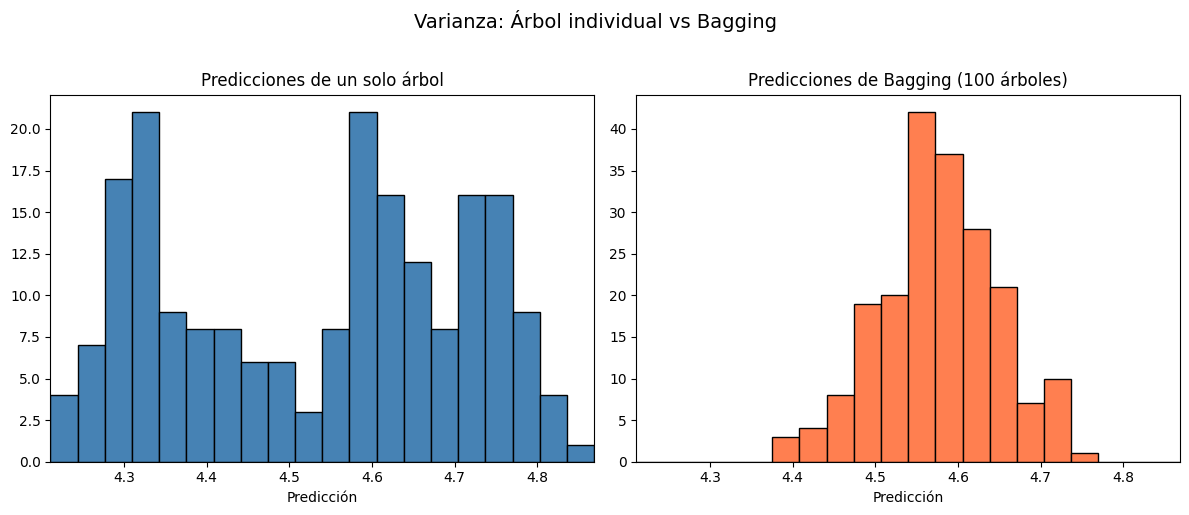

In [13]:
import pandas as pd
from sklearn.datasets import fetch_california_housing
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import BaggingRegressor
import matplotlib.pyplot as plt
import numpy as np

# Cargar California Housing Dataset
california = fetch_california_housing()
X = pd.DataFrame(california.data, columns=california.feature_names)
y = pd.Series(california.target)

# Crear 200 árboles individuales vs bagging
tree_preds = []
bagging_preds = []

for i in range(200):
    # Bootstrap sampling
    bootstrap_indices = np.random.choice(np.arange(len(X)), size=len(X), replace=True)
    X_boot = X.iloc[bootstrap_indices]
    y_boot = y.iloc[bootstrap_indices]

    tree = DecisionTreeRegressor(max_depth=4)
    tree.fit(X_boot, y_boot)
    tree_preds.append(tree.predict([X.iloc[0]])[0])

    bag = BaggingRegressor(estimator=DecisionTreeRegressor(max_depth=4), n_estimators=100)
    bag.fit(X_boot, y_boot)
    bagging_preds.append(bag.predict([X.iloc[0]])[0])

# Histogramas comparativos
bin_edges = np.linspace(min(tree_preds + bagging_preds), max(tree_preds + bagging_preds), 21)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

ax1.hist(tree_preds, bins=bin_edges, color='steelblue', edgecolor='black')
ax1.set_title('Predicciones de un solo árbol')
ax1.set_xlim(bin_edges[0], bin_edges[-1])
ax1.set_xlabel('Predicción')

ax2.hist(bagging_preds, bins=bin_edges, color='coral', edgecolor='black')
ax2.set_title('Predicciones de Bagging (100 árboles)')
ax2.set_xlim(bin_edges[0], bin_edges[-1])
ax2.set_xlabel('Predicción')

plt.suptitle('Varianza: Árbol individual vs Bagging', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

# Feature Importance

Una de las mayores ventajas de los árboles de decisión es que nos dicen **qué variables son más importantes** para la predicción. La importancia se calcula como la reducción total de impureza (Gini o MSE) que produce cada variable a lo largo del árbol.

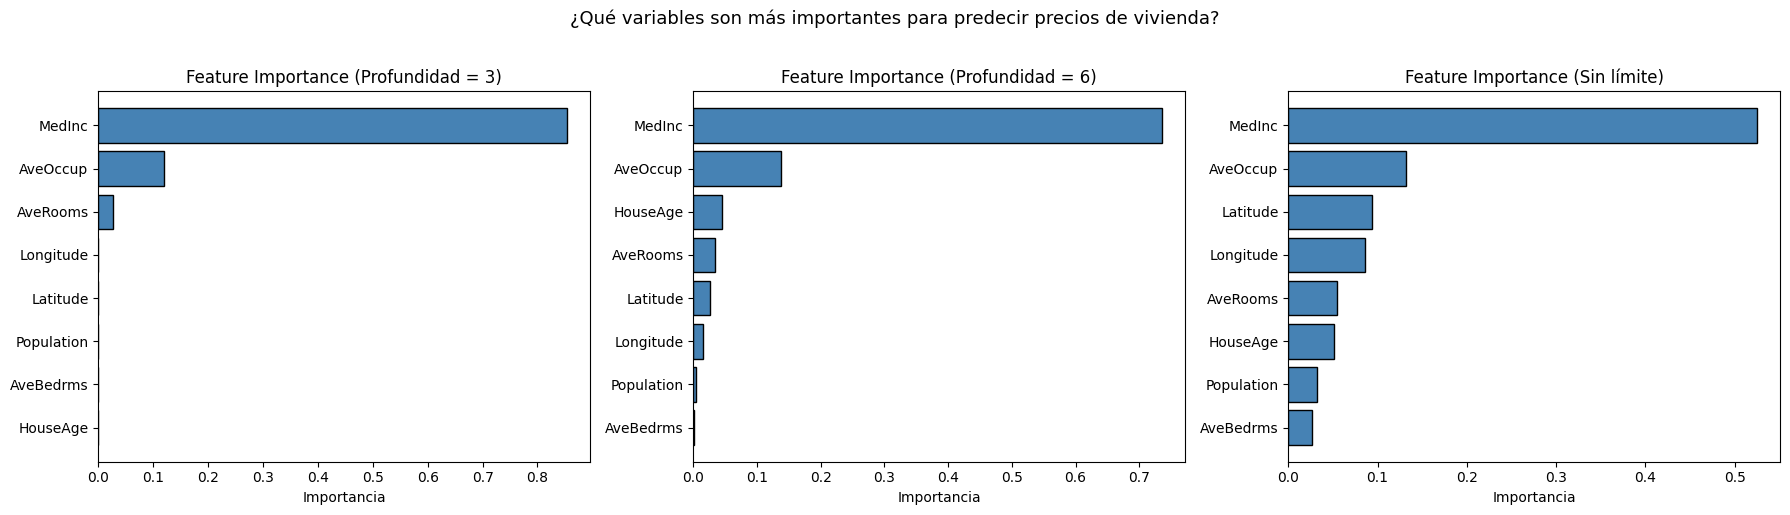

Observación: MedInc (ingreso mediano) domina en todos los casos.
Pero la importancia de otras variables cambia con la profundidad del árbol.
Esto es una limitación: la importancia depende de la estructura específica del árbol.


In [14]:
from sklearn.datasets import fetch_california_housing
from sklearn.tree import DecisionTreeRegressor
import matplotlib.pyplot as plt
import numpy as np

# Cargar datos
california = fetch_california_housing()
X = california.data
y = california.target
feature_names = california.feature_names

# Entrenar árboles con distintas profundidades
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, depth in zip(axes, [3, 6, None]):
    dt = DecisionTreeRegressor(max_depth=depth, random_state=42)
    dt.fit(X, y)
    
    importances = dt.feature_importances_
    sorted_idx = np.argsort(importances)
    
    ax.barh(range(len(feature_names)), importances[sorted_idx], color='steelblue', edgecolor='black')
    ax.set_yticks(range(len(feature_names)))
    ax.set_yticklabels([feature_names[i] for i in sorted_idx])
    ax.set_xlabel('Importancia')
    title = f'Profundidad = {depth}' if depth else 'Sin límite'
    ax.set_title(f'Feature Importance ({title})')

plt.suptitle('¿Qué variables son más importantes para predecir precios de vivienda?', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

print("Observación: MedInc (ingreso mediano) domina en todos los casos.")
print("Pero la importancia de otras variables cambia con la profundidad del árbol.")
print("Esto es una limitación: la importancia depende de la estructura específica del árbol.")

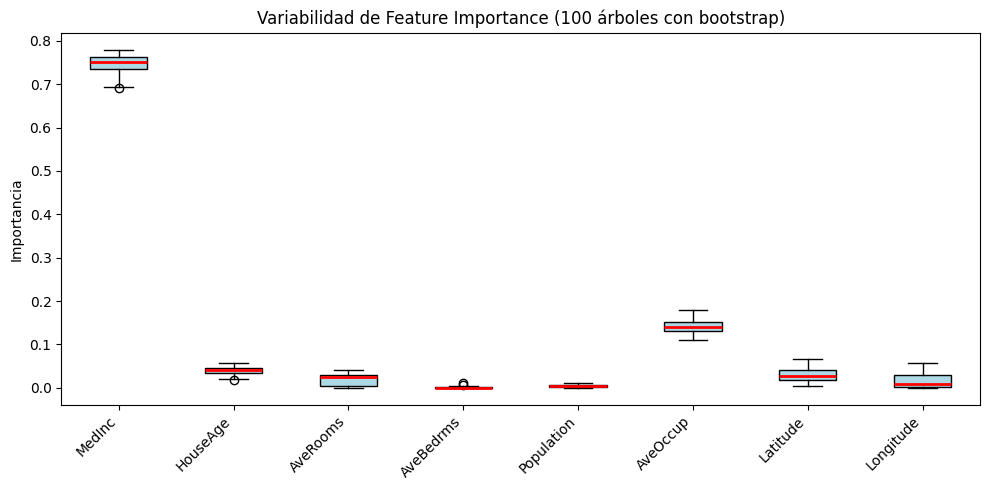

Las cajas muestran cuánto varía la importancia de cada variable entre distintos árboles.
Esto motiva el uso de Random Forest, que promedia sobre muchos árboles y da
importancias más estables.


In [21]:
# Comparar importancia de features entre múltiples árboles (bootstrap)
# Esto demuestra la inestabilidad de la feature importance en árboles individuales

importances_matrix = []
for i in range(100):
    idx = np.random.choice(len(X), size=10000, replace=True)
    dt = DecisionTreeRegressor(max_depth=5)
    dt.fit(X[idx], y[idx])
    importances_matrix.append(dt.feature_importances_)

importances_matrix = np.array(importances_matrix)

fig, ax = plt.subplots(figsize=(10, 5))
bp = ax.boxplot(importances_matrix, labels=feature_names, patch_artist=True,
                boxprops=dict(facecolor='lightblue', color='black'),
                medianprops=dict(color='red', linewidth=2))
ax.set_ylabel('Importancia')
ax.set_title('Variabilidad de Feature Importance (100 árboles con bootstrap)')
ax.set_xticklabels(feature_names, rotation=45, ha='right')
plt.tight_layout()
plt.show()

print("Las cajas muestran cuánto varía la importancia de cada variable entre distintos árboles.")
print("Esto motiva el uso de Random Forest, que promedia sobre muchos árboles y da")
print("importancias más estables.")

# Medidas de Impureza: Gini vs Entropía

Los árboles de clasificación usan medidas de **impureza** para decidir cómo dividir los datos. Las dos más comunes son:

- **Gini**: $G = 1 - \sum_{k} p_k^2$ — mide la probabilidad de clasificar incorrectamente una observación
- **Entropía**: $H = -\sum_{k} p_k \log_2(p_k)$ — mide el desorden o incertidumbre

En la práctica producen árboles muy similares. Veamos cuándo difieren.

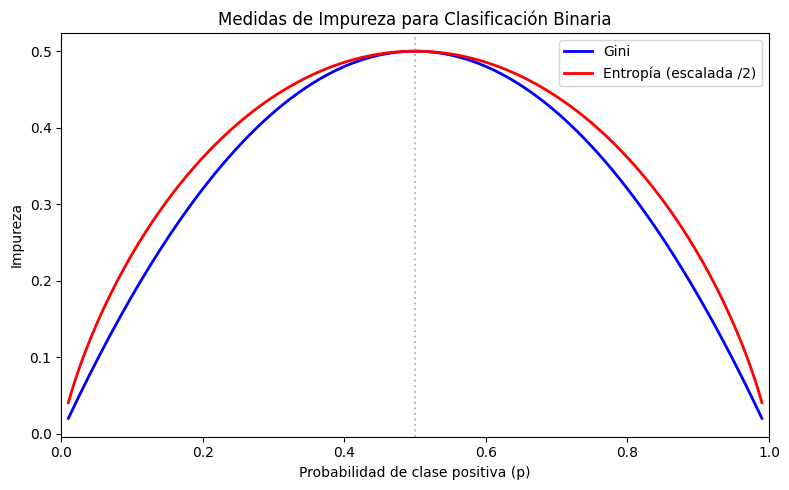

Ambas medidas alcanzan su máximo en p=0.5 (máxima incertidumbre).
Gini y Entropía son muy similares — por eso en la práctica casi no importa cuál usar.


In [16]:
import numpy as np
import matplotlib.pyplot as plt

# Comparar Gini vs Entropía como función de la probabilidad de clase
p = np.linspace(0.01, 0.99, 200)

gini = 2 * p * (1 - p)  # Gini para problema binario
entropy = -p * np.log2(p) - (1 - p) * np.log2(1 - p)

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(p, gini, 'b-', linewidth=2, label='Gini')
ax.plot(p, entropy / 2, 'r-', linewidth=2, label='Entropía (escalada /2)')
ax.set_xlabel('Probabilidad de clase positiva (p)')
ax.set_ylabel('Impureza')
ax.set_title('Medidas de Impureza para Clasificación Binaria')
ax.legend()
ax.axvline(x=0.5, color='gray', linestyle=':', alpha=0.5)
ax.set_xlim(0, 1)
plt.tight_layout()
plt.show()

print("Ambas medidas alcanzan su máximo en p=0.5 (máxima incertidumbre).")
print("Gini y Entropía son muy similares — por eso en la práctica casi no importa cuál usar.")

Accuracy con Gini:     0.960 ± 0.033
Accuracy con Entropía: 0.960 ± 0.033


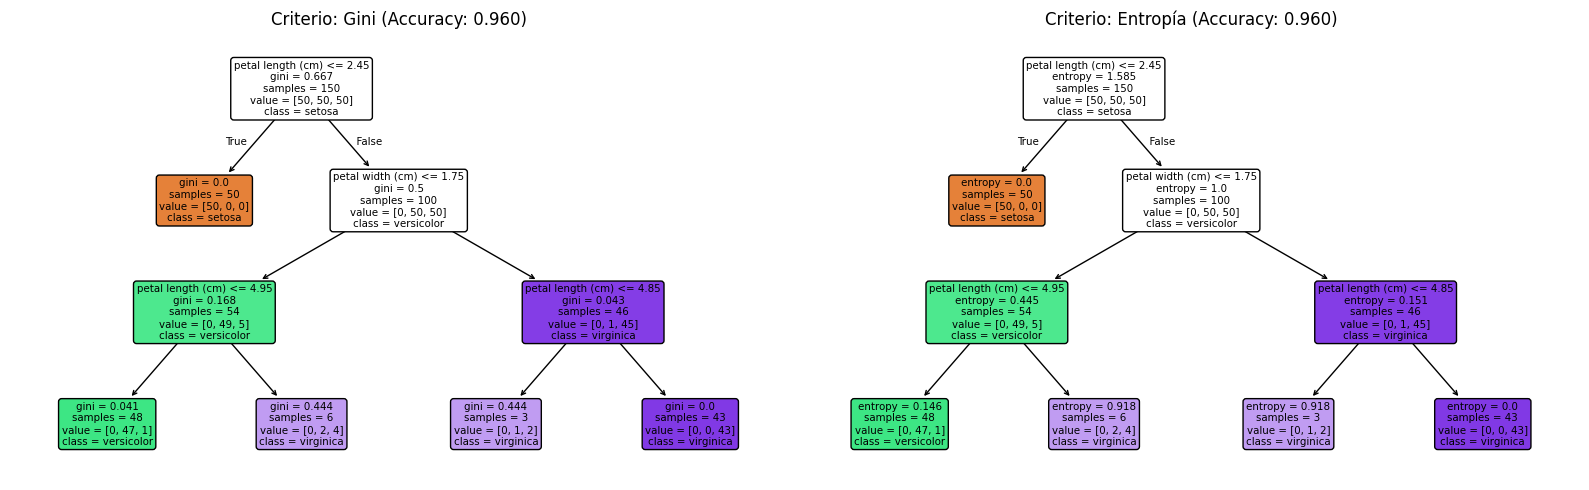


En la práctica, la diferencia suele ser mínima.
Gini es ligeramente más rápido (no requiere calcular logaritmos).


In [17]:
from sklearn.datasets import load_iris
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.model_selection import cross_val_score

# Comparar árboles entrenados con Gini vs Entropía en Iris
iris = load_iris()

dt_gini = DecisionTreeClassifier(max_depth=3, criterion='gini', random_state=42)
dt_entropy = DecisionTreeClassifier(max_depth=3, criterion='entropy', random_state=42)

# Cross-validation para comparar
scores_gini = cross_val_score(dt_gini, iris.data, iris.target, cv=10)
scores_entropy = cross_val_score(dt_entropy, iris.data, iris.target, cv=10)

print(f"Accuracy con Gini:     {scores_gini.mean():.3f} ± {scores_gini.std():.3f}")
print(f"Accuracy con Entropía: {scores_entropy.mean():.3f} ± {scores_entropy.std():.3f}")

# Visualizar ambos árboles
dt_gini.fit(iris.data, iris.target)
dt_entropy.fit(iris.data, iris.target)

fig, axes = plt.subplots(1, 2, figsize=(16, 5))
plot_tree(dt_gini, ax=axes[0], filled=True, feature_names=iris.feature_names,
          class_names=iris.target_names, rounded=True)
axes[0].set_title(f'Criterio: Gini (Accuracy: {scores_gini.mean():.3f})')

plot_tree(dt_entropy, ax=axes[1], filled=True, feature_names=iris.feature_names,
          class_names=iris.target_names, rounded=True)
axes[1].set_title(f'Criterio: Entropía (Accuracy: {scores_entropy.mean():.3f})')

plt.tight_layout()
plt.show()

print("\nEn la práctica, la diferencia suele ser mínima.")
print("Gini es ligeramente más rápido (no requiere calcular logaritmos).")

# Cost-Complexity Pruning (ccp_alpha)

En vez de limitar la profundidad del árbol *a priori*, el **cost-complexity pruning** primero crece el árbol completo y luego lo **poda** eliminando ramas que no aportan suficiente mejora.

Se controla con el parámetro `ccp_alpha` (α):
- α = 0: sin poda (árbol completo)
- α grande: poda agresiva (árbol pequeño)

La función objetivo que se minimiza es:

$$R_\alpha(T) = R(T) + \alpha |T|$$

Donde $R(T)$ es el error del árbol y $|T|$ es el número de hojas. A mayor α, más se penaliza la complejidad.

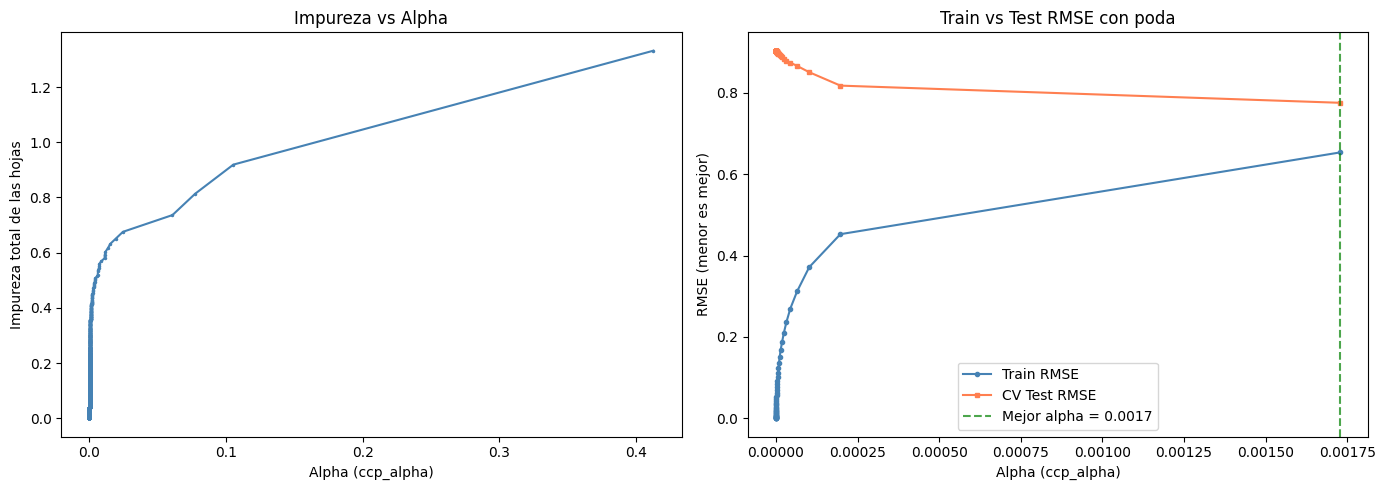

Alpha óptimo: 0.0017
RMSE en CV con alpha óptimo: 0.7754
RMSE en CV sin poda (alpha=0): 0.9034


In [18]:
from sklearn.datasets import fetch_california_housing
from sklearn.tree import DecisionTreeRegressor
from sklearn.model_selection import cross_val_score
import numpy as np
import matplotlib.pyplot as plt

# Cargar datos
california = fetch_california_housing()
X, y = california.data, california.target

# Paso 1: Obtener la ruta de poda (cost-complexity pruning path)
dt = DecisionTreeRegressor(random_state=42)
dt.fit(X, y)
path = dt.cost_complexity_pruning_path(X, y)
ccp_alphas = path.ccp_alphas
impurities = path.impurities

# Visualizar la ruta de poda
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ax = axes[0]
ax.plot(ccp_alphas, impurities, marker='.', markersize=3, color='steelblue')
ax.set_xlabel('Alpha (ccp_alpha)')
ax.set_ylabel('Impureza total de las hojas')
ax.set_title('Impureza vs Alpha')

# Paso 2: Entrenar árboles con distintos alphas y medir performance
# Tomamos un subconjunto de alphas para que sea más rápido
alphas_to_test = ccp_alphas[::max(1, len(ccp_alphas)//50)]  # ~50 valores
train_rmse = []
test_rmse = []

for alpha in alphas_to_test:
    dt_pruned = DecisionTreeRegressor(ccp_alpha=alpha, random_state=42)
    scores = cross_val_score(dt_pruned, X, y, cv=5, scoring='neg_mean_squared_error')
    test_rmse.append(np.sqrt(-scores.mean()))
    dt_pruned.fit(X, y)
    train_rmse.append(np.sqrt(np.mean((y - dt_pruned.predict(X))**2)))

ax = axes[1]
ax.plot(alphas_to_test, train_rmse, 'o-', label='Train RMSE', markersize=3, color='steelblue')
ax.plot(alphas_to_test, test_rmse, 's-', label='CV Test RMSE', markersize=3, color='coral')
ax.set_xlabel('Alpha (ccp_alpha)')
ax.set_ylabel('RMSE (menor es mejor)')
ax.set_title('Train vs Test RMSE con poda')
ax.legend()

# Marcar el alpha óptimo
best_idx = np.argmin(test_rmse)
best_alpha = alphas_to_test[best_idx]
ax.axvline(x=best_alpha, color='green', linestyle='--', alpha=0.7, label=f'Mejor alpha = {best_alpha:.4f}')
ax.legend()

plt.tight_layout()
plt.show()

print(f"Alpha óptimo: {best_alpha:.4f}")
print(f"RMSE en CV con alpha óptimo: {test_rmse[best_idx]:.4f}")
print(f"RMSE en CV sin poda (alpha=0): {test_rmse[0]:.4f}")

In [19]:
# Comparar el árbol sin poda vs el árbol podado
from sklearn.tree import plot_tree

dt_full = DecisionTreeRegressor(random_state=42)
dt_full.fit(X, y)

dt_pruned = DecisionTreeRegressor(ccp_alpha=best_alpha, random_state=42)
dt_pruned.fit(X, y)

print(f"Árbol sin poda:  {dt_full.get_n_leaves()} hojas, profundidad {dt_full.get_depth()}")
print(f"Árbol podado:    {dt_pruned.get_n_leaves()} hojas, profundidad {dt_pruned.get_depth()}")
print(f"Reducción:       {(1 - dt_pruned.get_n_leaves()/dt_full.get_n_leaves()):.4%} menos hojas")

Árbol sin poda:  19816 hojas, profundidad 40
Árbol podado:    51 hojas, profundidad 9
Reducción:       99.7426% menos hojas
